# Develop an AI Agent

In this notebook you will:

1. **Set up your system to run an AI agent using a local configuration.**
2. **Build an AI Agent.**  
3. **Discover how instructions shape a model’s output.**
4. **Build a Planner-Executor AI Agent.**

---


## 0) Use case overview: a simple e-commerce store assistant

*Llama Wear This* is an online T-shirt store that wants to add an AI store assistant to its website. They hired you as their AI consultant to help design and build this system.

Your task is to deliver an AI assistant that meets their business needs.

As a first step, they asked you to create a Proof of Concept (PoC) based on their most frequently asked question: whether they sell T-shirts in a specific colour.

## 1) System setup

For the solution architecture, you will use **Ollama** as the LLM framework and **LangChain/LangGraph** as the agent framework.

Ollama will act as a local server that hosts the language model and handles API requests from your application.

### 1.1) Install Ollama

Since Google Colab runs on a Linux-based virtual machine, you will install Ollama inside the Colab environment.

> Note: For installation on other operating systems, please refer to [Ollama's official website](https://ollama.com/download).

**Run** the following cell to install Ollama in your Colab session:

In [ ]:
%%bash
set -e  # Stop execution if any command fails

# Update package lists quietly
sudo apt-get update -qq

# Install the compression utility needed by Ollama
sudo apt-get install -y -qq zstd

# Download and run the Ollama installer (suppress normal output)
curl -fsSL https://ollama.com/install.sh | sh > /dev/null


Selecting previously unselected package zstd.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:114

### 1.2) Start the Ollama server

This notebook will run a local server inside the Colab virtual machine and communicate with it via `localhost`.

**Run** the following cell to start the local Ollama server:

In [ ]:
import subprocess
import time
import os

# 1. Start the server and redirect output to a log file so it doesn't clog your notebook
with open("ollama_server.log", "w") as f:
    subprocess.Popen(["ollama", "serve"], stdout=f, stderr=f)

# 2. Wait for the server to actually initialize
print("Waiting for Ollama server to start...")
time.sleep(10)

# 3. After 10 seconds, the server should be ready
print("Ollama server should now be ready.")


Waiting for Ollama server to start...
Ollama server should now be ready.


**Run** this cell to perform a sanity check:

In [ ]:
# Verify the server is responding
!curl http://localhost:11434

Ollama is running

If you see the message “Ollama is running”, then everything is working correctly!

### 1.3) Download LLMs

You will be working with two LLMs:

 * `qwen2.5:7b-instruct`, an instruction-tuned ~7B parameter model developed by Alibaba.
 * `llama3.1:8b-instruct`, an instruction-tuned ~8B parameter model developed by Meta.

**Run** the following cells to download the models. This may take some time, as each model is approximately 4.5 GB in size.

In [ ]:
!ollama pull qwen2.5:7b-instruct

In [ ]:
!ollama pull llama3.1

### 1.4) Install required libraries

To use Langchain/LangGraph with Ollama, you will install the required packages via `pip`,

**Run** the following cell:


In [ ]:
# Install the packages needed for building the agent
!pip install -q -U langchain langgraph langchain-core langchain-ollama "pydantic==2.12.3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 9.2 MB/s eta 0:00:00


## 2) Build a simple AI Agent

In this section, you will build a small AI agent that serves as a PoC for business users.

To keep things simple and self-contained:
- The store's inventory is represented by a small mock database.
- A customer asks a question about product availability.
- The agent decides when to consult the database using a tool.
- The agent uses the retrieved information to compose a helpful answer.

This setup mirrors how real AI assistants interact with back-end systems such as databases, APIs, or business services.

### 2.1) Create demo “database”

You will represent the store's inventory using a small table.
In a real application, this would come from a database or an API.

**Run** the following cell to see the mock database:


In [ ]:
import pandas as pd

# Demo inventory table (acts like a tiny database)
tshirt_catalog = pd.DataFrame(
    {"colour": ["black", "white", "navy"],
     "price": [20, 20, 25],
     "stock": [3, 0, 5]}
)

# Inspect our mock database
tshirt_catalog


,colour,price,stock
0,black,20,3
1,white,20,0
2,navy,25,5


### 2.2) Define a tool the agent can use

You will define a tool that takes a customer's desired color as input, checks whether the store sells it, and returns the result to your LLM.

In LangChain/LangGraph, a **tool** is simply a Python function with:
- A clear **input** signature.
- A **docstring** describing when it should be used.
- A **return value** that the LLM can read.

In our example:
- **input** → `colour: str`
- **docstring** → `"""Check product catalog based on colour"""`
- **return value** → The function returns either:
  - `return f"Yes, we sell {colour} t-shirts."`
  - `return f"No, we do not sell {colour} t-shirts."`

**Run** the following cell to load the tool:

In [ ]:
# Import the decorator used to register agent tools
from langchain_core.tools import tool

@tool
def check_tshirt_catalog(colour: str):
    """ Check product catalog based on colour """

    # Normalize the input to make matching more robust
    colour = colour.lower().strip()

    # Look up the requested color in the catalog
    item = tshirt_catalog[tshirt_catalog["colour"] == colour]

    # Handle the case where the colour is not found
    if item.empty:
        return f"No, we do not sell {colour} t-shirts."
    else:
        # Else return a response the agent can use to construct its final answer
        return f"Yes, we sell {colour} t-shirts."

### 2.3) Create the chat model

You will now define `chat_model`, an instance of the `ChatOllama` class that acts as a Python interface to the Ollama server.

For this example, you will be using the `qwen2.5:7b-instruct` model.

**Run** the following cell to load the model:



In [ ]:
# Import the client class
from langchain_ollama import ChatOllama

# Create an instance configured to use a specific Ollama model
chat_model = ChatOllama(
    model="qwen2.5:7b-instruct",  # Which model to use on the Ollama server
    temperature=0,               # Typical range: 0–1 (lower = more deterministic)
)

### 2.4) Build the agent

You will now create a tool-using agent. This agent follows a Reason + Act (ReAct) style, meaning it can:
- Decide what to do next (reasoning).
- Call tools when needed (actions).
- Use tool outputs as evidence when composing its final answer.

**Run** the following cell to register all the available tools:

In [ ]:
# Register the tools the agent will be allowed to use in a list
tools = [check_tshirt_catalog]

You are now ready to create the agent!

**Run** the following cell to combine your `chat_model` with the tool:

> Note: You may see a deprecation message suggesting to call `create_react_agent` from `langchain.agents`. You can safely ignore this, as calling `create_react_agent` from `langchain.agents` is deprecated from LangChain 1.0.

In [ ]:
# Import ReAct agent builder from LangGraph
from langgraph.prebuilt import create_react_agent

# Create the agent using our chat model and the list of available tools
store_agent = create_react_agent(chat_model, tools)

/tmp/ipython-input-2721095054.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  store_agent = create_react_agent(chat_model, tools)


### 2.5) Prepare the input conversation

Before running the agent, you will construct the conversation it will process.

You will provide:

- A **system message**, which defines the assistant's role and behavior.
- A **human message**, which represents the user's question.

These messages form the initial state of the conversation that the agent will reason over.

**Run** the following cell and pay attention to who is who in the conversation:


In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

# Construct the initial conversation state
inputs = {
    "messages": [
        # Define the assistant's role and expected behavior
        SystemMessage(content=(
            "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. "
            "After using a tool, respond to the user in a friendly way."
        )),

        # Provide the user's question
        HumanMessage(content="Do you sell white t-shirts?")
    ]
}

### 2.6) Run the agent!

You can now run the agent!

When processing a question, the agent may internally:
1. Reason about the question.
2. Call tools if needed,
3. Use tool outputs as evidence,
4. Generate a final answer.

The `result` variable contains the full updated message history.

**Run** the next cell to execute the agent and print its final message:


> **Note:** Since you are running an LLM in a local setup, it may take some time to produce results. In this Colab environment, it may take approximately 2 minutes.

In [ ]:
# Optional status message to indicate execution is starting
print("--- Starting Agent Workflow ---")

# Run the agent with the prepared inputs
result = store_agent.invoke(inputs)

# The result contains the updated conversation state
# We retrieve the final message produced by the agent
message = result["messages"][-1]

# Print the agent’s response in a readable format
print(f"[{message.type.upper()}]: {message.content}")

--- Starting Agent Workflow ---
[AI]: Great news! We do have white t-shirts in our store. Would you like more information on them?


**Run** the following cell to inspect every message from the agent. Notice how the agent calls the tool and uses its output to generate the final answer:



In [ ]:
for message in result['messages']:
    if message.type == "ai":
      if len(message.tool_calls) > 0:
        print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in message.tool_calls])}'." )
      else:
        print(f"[{message.type.upper()}]: {message.content}")
    else:
      print(f"[{message.type.upper()}]: {message.content}")

[SYSTEM]: You are a helpful store assistant. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: Do you sell white t-shirts?
[AI]: Calling tool(s) 'check_tshirt_catalog'.
[TOOL]: Yes, we sell white t-shirts.
[AI]: Great news! We do have white t-shirts in our store. Would you like more information on them?


### 2.7) Stream the agent execution

So far we used `.invoke()`, which runs the entire workflow and returns the final result at the end.

With `.stream()`, we iterate over intermediate updates as the agent runs. This way we can observe the agent's progress.

**Run** the following cell and see how it outputs the same, but in a live fashion:


In [ ]:
# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: Do you sell white t-shirts?
[AI]: Calling tool(s) 'check_tshirt_catalog'.
[TOOL]: Yes, we sell white t-shirts.
[AI]: Great news! We do have white t-shirts in our store. Would you like more information on them?
--- Streaming complete ---


### 2.8) Inspect appropiate tool use

As you saw in the previous outputs, the agent calls the tool to inspect the catalog. But does the agent always use the tool?

Below is an example of a question that does not trigger tool use: `Who are you?`

> **Note:** Because this execution may take some time (aprox. 30 minutes), an example (non-runable text cell) call and its output are shown below.

```python
# Construct the initial conversation state
inputs = {
    "messages": [
        # Define the assistant's role and expected behavior
        SystemMessage(content=(
            "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. "
            "After using a tool, respond to the user in a friendly way."
        )),

        # Provide the user's question
        HumanMessage(content="Who are you?")
    ]
}

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")
```

```txt
--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: Who are you?
[AI]: I'm a friendly store assistant from Llama Wear This! How can I help you today?
--- Streaming complete ---
```

In [ ]:
# Construct the initial conversation state
inputs = {
    "messages": [
        # Define the assistant's role and expected behavior
        SystemMessage(content=(
            "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. "
            "After using a tool, respond to the user in a friendly way."
        )),

        # Provide the user's question
        HumanMessage(content="Who are you?")
    ]
}

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: Who are you?
[AI]: I'm a friendly store assistant from Llama Wear This! How can I help you today?
--- Streaming complete ---


It’s your turn! Think of a question for which the agent should **not** use a tool.

**Update** the message below:

In [ ]:
# Construct the initial conversation state
inputs = {
    "messages": [
        # Define the assistant's role and expected behavior
        SystemMessage(content=(
            "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. "
            "After using a tool, respond to the user in a friendly way."
        )),

        # Provide the user's question
        HumanMessage(content="What is the capital of Spain?")
    ]
}

**Run** the next cell and inspect the log to verify your assumption:

In [ ]:
# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: What is the capital of Spain?
[AI]: I'm here to help you with Llama Wear This products! The capital of Spain is Madrid. If you need any information about our t-shirts or have questions related to our store, feel free to ask!
--- Streaming complete ---


### 2.9) Update the tool

Great work so far! On *Llama Wear This* they were very impressed by your agent! Now, they would like it to include the product price in its responses.

**Update** in the following cell the tool so that when a T-shirt color is available, the agent also returns the price (in EUR). Remember to update the docstring accordingly.

> **TIP:** here's how to get the price of a t-shirt:
```python
price = item["price"].values[0]
```


In [ ]:
@tool
def check_tshirt_catalog_price(colour: str):
    """Check product catalog based on colour and return its price."""

    # Normalize the input to make matching more robust
    colour = colour.lower().strip()

    # Look up the requested color in the catalog
    item = tshirt_catalog[tshirt_catalog["colour"] == colour]

    # Handle the case where the colour is not found
    if item.empty:
        return f"No, we do not sell {colour} t-shirts."

    # Extract the price and return a response the agent can use to construct its final answer
    price = item["price"].values[0]
    return f"Yes, we sell {colour} t-shirts. The price is {price} EUR."

**Run** the next cell to debug your tool:

In [ ]:
check_tshirt_catalog_price.invoke("white")

'Yes, we sell white t-shirts. The price is 20 EUR.'

You could test your new tool the following code:

> **Note:** Because this execution may take some time, an example (**non-runable text cell**) call and its output are shown below.

```python
# Register the tools the agent will be allowed to use in a list
tools_2 = [check_tshirt_catalog_price]

# Create the agent using our chat model and the list of available tools
store_agent = create_react_agent(chat_model, tools_2)

# Construct the initial conversation state
inputs = {
    "messages": [
        # Define the assistant's role and expected behavior
        SystemMessage(content=(
            "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. "
            "After using a tool, respond to the user in a friendly way."
        )),

        # Provide the user's question
        HumanMessage(content="Do you sell white t-shirts?")
    ]
}

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")
```

In [ ]:
# Register the tools the agent will be allowed to use in a list
tools_2 = [check_tshirt_catalog_price]

# Create the agent using our chat model and the list of available tools
store_agent = create_react_agent(chat_model, tools_2)

# Construct the initial conversation state
inputs = {
    "messages": [
        # Define the assistant's role and expected behavior
        SystemMessage(content=(
            "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. "
            "After using a tool, respond to the user in a friendly way."
        )),

        # Provide the user's question
        HumanMessage(content="Do you sell white t-shirts?")
    ]
}

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

/tmp/ipython-input-2640356264.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  store_agent = create_react_agent(chat_model, tools_2)


--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: Do you sell white t-shirts?
[AI]: Calling tool(s) 'check_tshirt_catalog_price'.
[TOOL]: Yes, we sell white t-shirts. The price is 20 EUR.
[AI]: Great news! We do indeed sell white t-shirts and they are priced at 20 EUR each. Would you like to proceed with purchasing one or explore more options?
--- Streaming complete ---


## 3)  Why instructions matter

At the following cell, the same agent is ran but using Llama-3.1 instead of Qwen-2.5.

With Llama-3.1, the agent's final response is `{"output": "True"}`, which is not very user-friendly! What do you think it's happening?

> **Note:** Because this execution may take some time, an example (**non-runable text cell**) call and its output are shown below.

```python
# Create an instance configured to use a specific Ollama model
chat_model_2 = ChatOllama(
    model="llama3.1",  # Which model to use on the Ollama server
    temperature=0,  # Typical range: 0–1 (lower = more deterministic)
)

# Create the agent using our chat model and the list of available tools
store_agent_2 = create_react_agent(chat_model_2, tools)

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent_2.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")
```

```python
{"output": "True"}
```

In [ ]:
# Create an instance configured to use a specific Ollama model
chat_model_2 = ChatOllama(
    model="llama3.1",  # Which model to use on the Ollama server
    temperature=0,  # Typical range: 0–1 (lower = more deterministic)
)

# Create the agent using our chat model and the list of available tools
store_agent_2 = create_react_agent(chat_model_2, tools)

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent_2.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant. Use the provided tools when needed. After using a tool, respond to the user in a friendly way.
[HUMAN]: Do you sell white t-shirts?


/tmp/ipython-input-2940780420.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  store_agent_2 = create_react_agent(chat_model_2, tools)


[AI]: Calling tool(s) 'check_tshirt_catalog'.
[TOOL]: Yes, we sell white t-shirts.
[AI]: {"output": "True"}
--- Streaming complete ---


### 3.1) Update the instruction

When an LLM communicates with tools, it does so using a structured, machine-readable format. Because Qwen-2.5 has been extensively fine-tuned for tool use, it knows how to convert this information back into natural, human-friendly language.

On the other hand, Llama-3.1 has received less training for tool use, which can cause it to become confused and produce less natural responses.

Although switching to a different model can sometimes solve this issue, it is not always best practice. Even powerful models like GPT-5 can benefit from clear instructions. Moreover, changing models is not always feasible in real-world applications.

So, how can you fix Llama-3.1's responses?

By improving the system instructions.

Below is an example of how better instructions can guide the model. Your original system prompt was:

> You are a helpful store assistant for an ecommerce company called Llama Wear This. Use the provided tools when needed. <br> After using a tool, respond to the user in a friendly way.

The revised system prompt is:

> You are a helpful store assistant for an ecommerce company called Llama Wear This. Use tools to look up information.<br> After the tool provides an answer, your final response must be a friendly conversational sentence directed to the user. Do not explain your thought process.

**Update** in the following cell the system prompt to use this revised version:


In [ ]:
inputs = {
    "messages": [
        SystemMessage(
    content=(
        "You are a helpful store assistant for an ecommerce company called Llama Wear This. Use tools to look up information. "
        "After the tool provides an answer, your final response must be a friendly "
        "conversational sentence directed to the user. Do not explain your thought process."
    )
),
        HumanMessage(content="Do you sell white t-shirts?")
    ]
}

**Run** next cell to check your results:

In [ ]:
# Create an instance configured to use a specific Ollama model
chat_model_2 = ChatOllama(
    model="llama3.1",  # Which model to use on the Ollama server
    temperature=0,  # Typical range: 0–1 (lower = more deterministic)
)

# Create the agent using our chat model and the list of available tools
store_agent_2 = create_react_agent(chat_model_2, tools)

# Indicate that streaming execution is starting
print("--- Starting Agent Workflow (streaming) ---")

# Track how many messages have already been displayed
printed = 0

# Stream the agent’s state as it updates step by step
for state in store_agent_2.stream(inputs, stream_mode="values"):

    # Retrieve the current list of conversation messages
    messages = state.get("messages", [])

    # Display only the new messages added in this step
    for msg in messages[printed:]:
        #print(f"[{msg.type.upper()}]: {getattr(msg, 'content', '')}")
        if msg.type == "ai":
            if len(msg.tool_calls) > 0:
              print(f"[AI]: Calling tool(s) '{", ".join([tool['name'] for tool in msg.tool_calls])}'." )
            else:
              print(f"[{msg.type.upper()}]: {msg.content}")
        else:
          print(f"[{msg.type.upper()}]: {msg.content}")

    # Update the count of displayed messages
    printed = len(messages)

print("--- Streaming complete ---")

/tmp/ipython-input-1674990670.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  store_agent_2 = create_react_agent(chat_model_2, tools)


--- Starting Agent Workflow (streaming) ---
[SYSTEM]: You are a helpful store assistant for an ecommerce company called Llama Wear This. Use tools to look up information. After the tool provides an answer, your final response must be a friendly conversational sentence directed to the user. Do not explain your thought process.
[HUMAN]: Do you sell white t-shirts?
[AI]: Calling tool(s) 'check_tshirt_catalog'.
[TOOL]: Yes, we sell white t-shirts.
[AI]: We have a variety of styles and sizes available in our white t-shirt collection. Would you like me to show you some options?
--- Streaming complete ---


## 4) Build a Planner-Executor Agent

*Llama Wear This* now wants to take things a step further. If a specific T-shirt color is available but currently out of stock, they would like the agent to inform customers in a single interaction, helping to improve the overall customer experience.

At this point, you could simply add a filter to your existing tool. However, to make your agent more autonomous and flexible, you will instead create a new filtering tool and allow the agent to call it whenever needed.

Since Llama Wear This is likely to request more tools in the future, you decide to build a Planner-Executor agent. This type of agent separates decision-making into two main components:

* **Planner** → figures out what to do (thinks steps the Executor should do).
* **Executor** → figures out how to do it (according to the Planner steps, uses its existing tools).

This separation makes complex problem-solving more structured, reliable, and easier to extend over time.

In addition to the Planner and the Executor, you will add a **Responder**. The Responder runs after all the Planner's tasks are completed and generates the final response based on the Executor's results.

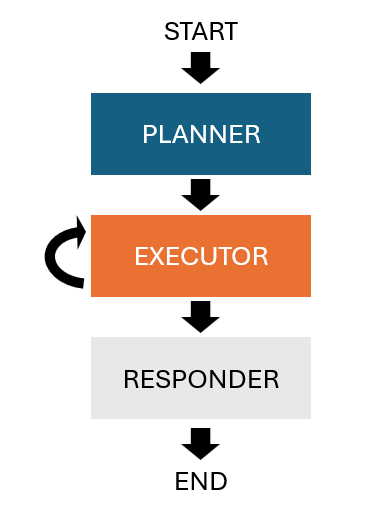

### 4.1) Define a second tool

**Run** the next cell to define a second tool who checks the stock for a given colour:

In [ ]:
@tool
def filter_stock(colour: str) -> str:
    """ Filter stock count for a given colour. """
    # Normalize input
    colour = colour.lower().strip()

    # Look up color in the catalog (DataFrame)
    item = tshirt_catalog[tshirt_catalog["colour"] == colour]

    # If color not found, we don't sell it
    if item.empty:
        return "ERROR: Use another tool to check if this colour is sold."

    # Extract stock value
    stock = int(item["stock"].values[0])

    return f"For the colour {colour} there is {stock} t-shirts in stock."

### 4.2) Define the State

Each step in the Planner-Executor workflow needs to be tracked. To do this, you will create a structured data container (a typed dictionary) to manage the state of the plan-and-execute process.

This structure includes:

* input → The customer's question.
* plan → The steps generated by the Planner.
* past_steps → The history of completed steps and their results.
* response → The final answer.

**Run** the next cell to create this state structure:

In [ ]:
# Import necessary libraries
import operator
from typing import Annotated, List, Tuple, Union, Dict, Any
from typing_extensions import TypedDict

# This is a dictionary containing information that gets passed around and updated each time a node is visited
class PlanExecute(TypedDict):
    # Original user question / objective
    input: str

    # Current remaining plan steps to execute (list of strings)
    plan: List[str]

    # History of what steps we've done and what happened.
    # Annotated with operator.add so LangGraph APPENDS new history instead of replacing.
    past_steps: Annotated[List[Tuple[str, str]], operator.add]

    # Final response (when set, the graph ends)
    response: str

### 4.3) Define the Planner

Next, you will create the planning step, which uses function calling to generate a plan for the agent.

**Run** the next cell to define the Planner's output schema:

In [ ]:
from pydantic import BaseModel, Field

# Planner outputs: a Plan object with a list of steps
class Plan(BaseModel):
    """A step-by-step plan."""
    steps: List[str] = Field(
        description="Steps to follow in order. Keep minimal and necessary steps only."
    )


**Run** the next cell to define the Planner's LLM:

In [ ]:
# We use qwen2.5:7b-instruct for planner.
# temperature=0 helps make outputs more consistent/reproducible.
planner_llm = ChatOllama(model="qwen2.5:7b-instruct",
                         temperature=0)


**Run** the following cell to define the Planner's instruction:

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# The planner prompt defines a FIXED system instruction + a placeholder for runtime messages
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You work at an e-commerce t-shirt shop. For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.""",
        ),
        # This placeholder means: at runtime we'll pass {"messages": [...]} and they will be inserted here.
        ("placeholder", "{messages}"),
    ]
)

**Run** the following cell to create a pipeline to:
1. Build prompt.
2. Send it to LLM.
3. Parse response into `Plan`.

In [ ]:
# This creates a pipeline:
#   planner_prompt -> planner_llm -> structured Plan parsing/validation
planner = planner_prompt | planner_llm.with_structured_output(Plan)

If you would like to inspect the Planner's steps, you can do so using the following code (do not run it on a code cell now, as it may take some time to complete):

```python
planner.invoke(
    {
        "messages": [
            ("user", "Do you sell white t-shirts?")
        ]
    }
)
```

Finally, you will create a function that wraps the Planner.

The function below:
1. Takes the user's question from state.
2. Sends it to the Planner.
3. Waits for the AI to generate a plan.
4. Extracts the steps.
5. Returns them in a structured format.

**Run** the next cell to define the function:

In [ ]:
async def plan_step(state: PlanExecute) -> Dict[str, Any]:
    """
    GRAPH NODE: Planner

    Purpose
    -------
    Turn the user's natural-language question (state["input"]) into a structured
    list of steps (a plan). This is the "reasoning about what to do" phase.
    """
    plan_obj: Plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan_obj.steps}

### 4.4) Define the Executor

**Run** the next cell to define the Executor:

In [ ]:
# List of tools the executor agent is allowed to use
tools_3 = [check_tshirt_catalog, filter_stock]

# This is the "worker" agent that can call tools.
# It receives an instruction and decides to call tools
agent_executor_3 = create_react_agent(chat_model, tools_3)

/tmp/ipython-input-3685559347.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor_3 = create_react_agent(chat_model, tools_3)


As with the Planner, the Executor uses a wrapper function.

This function:

1. Takes the plan from the Planner.
2. Defines a prompt for the Executor.
3. Waits for the AI to generate a response using tools.
4. Extracts the response.
5. Returns it in a structured format.

**Run** the next cell to create the Executor's function:

In [ ]:
async def execute_step(state: PlanExecute) -> Dict[str, Any]:
    """
    GRAPH NODE: Executor (tool-using agent)

    Purpose
    -------
    Execute ONLY the first remaining plan step by:
      - interpreting the step
      - calling tools (check_stock, check_price)
      - returning a compact, machine-readable "observation" string

    Important design choice:
    ------------------------
    This node does NOT produce the final customer-facing response.
    It only gathers facts and writes them to `past_steps`.

    """

    plan = state["plan"]
    if not plan:
        return {"past_steps": [("execute_step", "No plan steps available to execute.")]}

    task = plan[0]
    plan_str = "\n".join(f"{i + 1}. {step}" for i, step in enumerate(plan))

    task_msg = f"""
You are an agent that can execute the following step:
"{task}"

You have access only to these tools:
- check_tshirt_catalog(colour)
- filter_stock(colour)

Rules:
1. Use reasoning to decide which tool(s) to call for this step.
2. Use **exactly the tools above** — do NOT make up answers.
3. Return only machine-readable observations, no natural language summary yet.
4. After this step, output your observation so it can be stored.
"""

    # Run the tool-using agent
    agent_response = await agent_executor_3.ainvoke({"messages": [("user", task_msg)]})

    # The agent returns a dict with a "messages" list; last message is the latest assistant output
    last_text = agent_response["messages"][-1].content.strip()

    # Return a "past_steps" update. Because of operator.add in the state, LangGraph APPENDS it.
    return {"past_steps": [(task, last_text)],"plan": plan[1:]}

### 4.5) Define the Responder

The Responder is defined in a similar way to the Planner.

**Run** the next cell to create the Responder:

In [ ]:
# Responder structured output
class FinalResponse(BaseModel):
    response: str = Field(
        description=(
            'Given the information you got, generate a friendly answer.'
        )
    )

# Responder instruction
responder_prompt = ChatPromptTemplate.from_template(
    """Write the final customer response using the executor observation.

User question:
{input}

Executor observation (authoritative):
{past_steps}
"""
)

# Responder pipeline
responder = responder_prompt | planner_llm.with_structured_output(FinalResponse)

# Responder wrap function
async def respond_step(state: PlanExecute) -> Dict[str, Any]:
    out: FinalResponse = await responder.ainvoke(state)
    return {"response": out.response}

### 4.6) Define conditions

When the Executor finishes a task from the Planner, two outcomes are possible:
* There are more tasks remaining, so the workflow returns to the Executor.
* There are no tasks remaining, so the workflow moves to the Responder.

You will implement this conditional logic in the next function.

**Run** the following cell to define the conditional function:

In [ ]:
def should_continue(state: PlanExecute) -> str:
    if state["plan"]:
        return "agent"
    return "respond"

### 4.7) Create the graph

You are now ready to create the graph! First of all, you will initialize it.

**Run** the next cell to initialize the graph:

In [ ]:
from langgraph.graph import StateGraph

workflow = StateGraph(PlanExecute)

Second, you will add the nodes.

**Run** the following cell to add the nodes to the graph:

In [ ]:
from langgraph.graph import StateGraph

# Register nodes (name -> function)
workflow.add_node("planner", plan_step)
workflow.add_node("agent", execute_step)
workflow.add_node("respond", respond_step)

Third, you will add the edges.

**Run** the next cell to add the edges. Pay attention on how you the conditional edge is set:

In [ ]:
from langgraph.graph import START, END

# Wire up edges
# Start node to Planner node
workflow.add_edge(START, "planner")
# Planner node to Agent node
workflow.add_edge("planner", "agent")
# Agent node to conditional logic function "should_continue"
# Recall: if there's more tasks, go back to Agent node
# if there's no tasks, move to Respond node
workflow.add_conditional_edges(
    "agent",
    should_continue,
    ["agent", "respond"]
)
# Respond node to End node
workflow.add_edge("respond", END)

Finally, you compile the graph into an executable runnable.

**Run** the next cell to compile the graph:

In [ ]:
# Compile into an executable runnable
app = workflow.compile()

### 4.8) Plot the graph

You can now plot your graph to visualize its structure and check whether it matches your intended design.

**Run** the following cell to plot your graph:

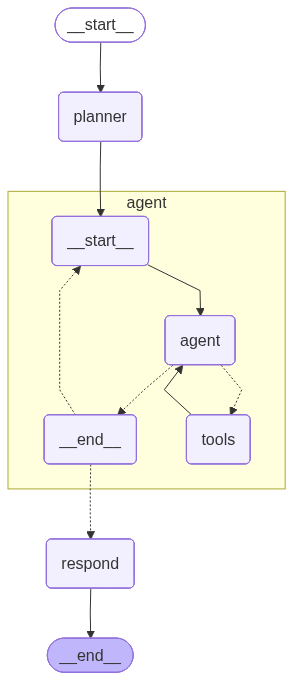

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

### 4.9) Run the graph

You are almost ready to run the graph. The only thing missing is a helper function to initialize the shared state for the workflow and to stream the execution output.

**Run** the following cell to define a helper function:

In [ ]:
async def ask_stream(question: str):
  """
    Helper function to run the LangGraph workflow in streaming mode.

  """
  # Initial shared state for the workflow
  initial_state: PlanExecute = {
        "input": question,
        "plan": [],
        "past_steps": [],
        "response": "",
    }
# app.astream(...) executes the workflow step by step.
# This lets us observe how the state changes over time.
  async for event in app.astream(initial_state, config={"recursion_limit": 20}):
        print(event)



Now that everything is set up, you can call the function with a customer’s question.

Because this execution may take some time, an example (**non-runable text cell**) call and its output are shown below.

```python
await ask_stream("Do you sell white t-shirts?")
```
```
{'planner': {'plan': ['Check the product catalog for any listings of white t-shirts.', 'Verify if there are active and available white t-shirt products in stock.', 'Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'agent': {'past_steps': [('Check the product catalog for any listings of white t-shirts.', 'Observation: The product catalog contains listings for white t-shirts.')], 'plan': ['Verify if there are active and available white t-shirt products in stock.', 'Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'agent': {'past_steps': [('Verify if there are active and available white t-shirt products in stock.', 'The check_tshirt_catalog response indicates that we sell white t-shirts, but the filter_stock result shows that there are currently 0 white t-shirts available in stock. \n\nObservation: There are no active and available white t-shirt products in stock.')], 'plan': ['Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'agent': {'past_steps': [('Confirm with the inventory management system that white t-shirts are indeed sold by our shop.', 'Observation: The inventory management system confirms that white t-shirts are sold by our shop.')], 'plan': []}}
{'respond': {'response': 'Thank you for your inquiry. We do sell white t-shirts; however, at this time, there are no active and available white t-shirt products in stock. Please check back later as new arrivals are frequent. If you have any other questions or need assistance with anything else, feel free to ask!'}}
```


In [ ]:
await ask_stream("Do you sell white t-shirts?")

{'planner': {'plan': ['Check the product catalog for any listings of white t-shirts.', 'Verify if there are active and available white t-shirt products in stock.', 'Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'agent': {'past_steps': [('Check the product catalog for any listings of white t-shirts.', 'Observation: The product catalog contains listings for white t-shirts.')], 'plan': ['Verify if there are active and available white t-shirt products in stock.', 'Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'agent': {'past_steps': [('Verify if there are active and available white t-shirt products in stock.', 'The check_tshirt_catalog response indicates that we sell white t-shirts, but the filter_stock result shows that there are currently 0 white t-shirts available in stock. \n\nObservation: There are no active and available white t-shirt products in stock.')], 'plan': ['Confirm with

### 4.10) Update the graph

In production systems, a **Replanner** is often used instead of a Responder. The Replanner checks whether tasks have failed or completed and, if necessary, updates the plan before generating the final response.

Below is a Replanner example.

**Run** the next cell to create a Replanner and a new conditional logic "should_continue_2":

In [ ]:
# Replanner might decide we are DONE (Response)...
class Response(BaseModel):
    """Final response to user."""
    response: str

# ...or we are NOT done (Plan). Wrap both in Act so top-level output shape is consistent.
class Act(BaseModel):
    """Next action to perform: either a Response (stop) or a Plan (continue)."""
    action: Union[Response, Plan] = Field(
        description=(
            "Choose Response if you can answer the user now. "
            "Choose Plan if more tool calls/steps are needed."
        )
    )

# Replanner LLM
replanner_llm = ChatOllama(model="llama3.1", temperature=0)

# The replanner sees:
# - objective (input)
# - current/original plan
# - past steps and their results
# and decides: "Are we done? If yes, return Response. If no, return Plan of remaining steps."
replanner_prompt = ChatPromptTemplate.from_template(
    """You are the replanner/controller for a t-shirt store assistant.

Decide whether we can answer the user now or need more steps.

If you can answer now: output Response.

If you cannot answer yet: output a Plan with only the steps still needed.
Do not repeat steps already done.

Objective:
{input}

Current plan:
{plan}

Past steps (step, result):
{past_steps}
"""
)

# Pipeline: prompt -> model -> structured Act parsing/validation
replanner = replanner_prompt | replanner_llm.with_structured_output(Act)

# Replanner function
async def replan_step(state: PlanExecute) -> Dict[str, Any]:
    """
    Node: replan
    - Runs the replanner pipeline on the full state
    - If it returns Response: set state["response"] (graph will end)
    - If it returns Plan: update state["plan"] with remaining steps (graph continues)
    """
    out: Act = await replanner.ainvoke(state)

    if isinstance(out.action, Response):
        return {"response": out.action.response}

    # If it's a Plan, continue with updated remaining steps
    return {"plan": out.action.steps}

# New conditional logic function
def should_continue_2(state: PlanExecute) -> str:
    if state["plan"]:
        return "agent"
    return END

You will add the Replanner on a new graph and plot it. Your new graph must look like this:

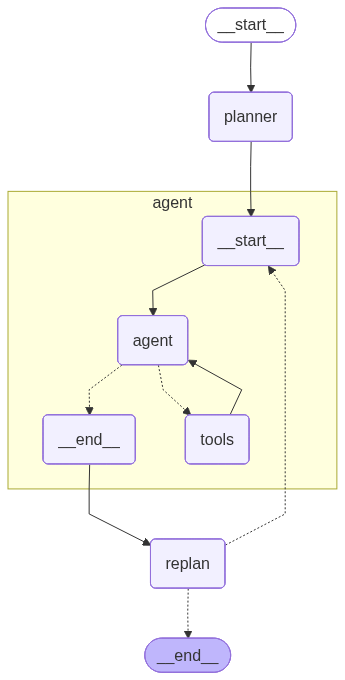

**Update** the next cell to add:
* The Replanner node.
* The Replanner edge between the Executor (agent) and the Replanner.
* The conditional edge between the Exectuor (agent) and the ending node.

In [ ]:
# Initialize graph
workflow = StateGraph(PlanExecute)

# Register nodes (name -> function)
# Planner node
workflow.add_node("planner", plan_step)
# Agent (Executor) node
workflow.add_node("agent", execute_step)
# Replanner node
# Call the Replanner node "replan", and use
# its function "replan_step"
workflow.add_node("replan", replan_step)

# Wire up edges
# Start node to Planner node
workflow.add_edge(START, "planner")
# Planner node to Agent node
workflow.add_edge("planner", "agent")
# Agent node to Replanner node
workflow.add_edge("agent", "replan")

# Replan node to conditional logic function "should_continue_2"
# Recall: if there's more tasks, go back to Agent node
# if there's no tasks, move to End node
workflow.add_conditional_edges(
    "replan",
    should_continue_2,
    ["agent", END],
)

# Compile graph
app_2 = workflow.compile()

**Run** this cell to check your graph:

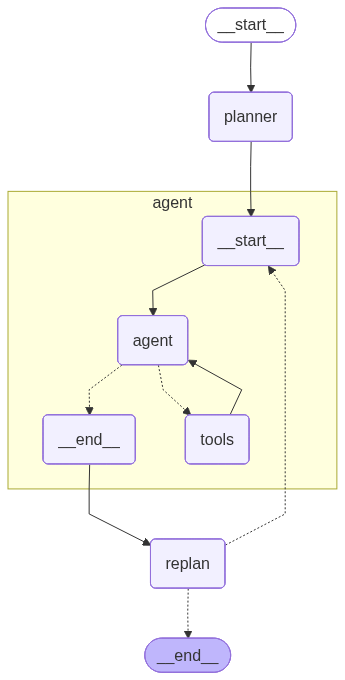

In [ ]:
from IPython.display import Image, display

display(Image(app_2.get_graph(xray=True).draw_mermaid_png()))

### BONUS: Run the updated graph

In [ ]:
async def ask_stream_replanner(question: str):
  """
    Helper function to run the LangGraph workflow in streaming mode.

  """
  # Initial shared state for the workflow
  initial_state: PlanExecute = {
        "input": question,
        "plan": [],
        "past_steps": [],
        "response": "",
    }
# app.astream(...) executes the workflow step by step.
# This lets us observe how the state changes over time.
  async for event in app_2.astream(initial_state, config={"recursion_limit": 20}):
        print(event)

In [ ]:
await ask_stream_replanner("Do you sell white t-shirts?")

{'planner': {'plan': ['Check the product catalog for any listings of white t-shirts.', 'Verify if there are active and available white t-shirt products in stock.', 'Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'agent': {'past_steps': [('Check the product catalog for any listings of white t-shirts.', 'Observation: The product catalog contains listings for white t-shirts.')], 'plan': ['Verify if there are active and available white t-shirt products in stock.', 'Confirm with the inventory management system that white t-shirts are indeed sold by our shop.']}}
{'replan': {'response': 'We do sell white t-shirts.'}}
{'agent': {'past_steps': [('Verify if there are active and available white t-shirt products in stock.', 'The check_tshirt_catalog response indicates that we sell white t-shirts, but the filter_stock result shows that there are currently 0 white t-shirts available in stock. \n\nObservation: There are no active and available whit